In [1]:
%pip install shap --quiet
%pip install matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
USE_CPP = False


import sys
root_dir = sys.argv[1]

import lightgbm as lgb
import thrember
from pathlib import Path
import numpy as np
import time

THRESHOLD = 0.5

MODELS_PATH = Path("../../models")

# Step 0: Load the LightGBM model
model = lgb.Booster(model_file=MODELS_PATH / "EMBER2024_all.model")

if USE_CPP:
    from efe_cpp import FeatureExtractor
    extractor_cpp = FeatureExtractor()
else:
    extractor = thrember.PEFeatureExtractor()

def extract_feature(filename):
    with open(filename, "rb") as f:
        raw_bytes = f.read()

    if USE_CPP:
        X = extractor_cpp.extract_from_file(filename)
    else:
        # Step 1: Extract features (raw features in dict form)
        features = extractor.raw_features(raw_bytes)
        # Step 2: Vectorize the features into a numeric array
        X = extractor.process_raw_features(features)  # vectorize() expects a list
    return X

def inspect(filename):
    X = extract_feature(filename)

    start_time = time.perf_counter()
    score: np.float64 = model.predict([X])[0]
    end_time = time.perf_counter()

    duration = end_time - start_time
    
    return score, score >= THRESHOLD, duration, len(raw_bytes)


In [3]:
# Load test set
import numpy as np

X_test = []
for filename in [
    "Z:\\SHARED\\Firefox Installer.exe",
    "Z:\\SHARED\\HelloWorld.exe",
    "Z:\\SHARED\\ProcessHollowing.exe",
]:
    F = extract_feature(filename)
    X_test.append(F)

X_test = np.array(X_test)

In [4]:
dim = X_test[0].shape[0]
dim

2568

In [5]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values for test set
shap_values = explainer.shap_values(X_test)

c:\Users\LAMVT12\Desktop\projects\EMBER2024\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\LAMVT12\Desktop\projects\EMBER2024\venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [6]:
baseline = explainer.expected_value
baseline

np.float64(0.6279499810267867)

In [7]:
shap_values

array([[-0.019402  ,  0.01706596,  0.        , ...,  0.        ,
         0.        ,  0.10011328],
       [-0.00544813, -0.00795346,  0.        , ...,  0.        ,
         0.        , -0.18618415],
       [ 0.01656874, -0.01229614,  0.        , ...,  0.        ,
         0.        , -0.15886281]], shape=(3, 2568))

In [8]:
pred = model.predict([X_test[0]])[0]
pred

np.float64(0.0021633145084888113)

In [9]:
sum_shap = np.sum(shap_values[0])
sum_shap

np.float64(-6.76189806183023)

In [10]:
pred - (baseline + sum_shap)

np.float64(6.136111395311932)

In [11]:
import numpy as np
from scipy.special import logit, expit

x = np.array(X_test[0])

shap_vals = explainer.shap_values(np.array([x]))[0]
baseline = explainer.expected_value

logit_recon = baseline + shap_vals.sum()
prob_from_shap = expit(logit_recon)
prob_model = model.predict([x])[0]

print("Baseline:", baseline)
print("Model probability:", prob_model)
print("From SHAP:", prob_from_shap)
print("Difference:", prob_model - prob_from_shap)

Baseline: 0.6279499810267867
Model probability: 0.0021633145084888113
From SHAP: 0.0021633145086879875
Difference: -1.9917617902209805e-13


In [12]:
def logit(y):
    # Ensure y is within the valid range (0, 1) to avoid math errors
    if not (0 < np.min(y) and np.max(y) < 1):
        raise ValueError("Input 'y' must be in the range (0, 1)")
        
    return np.log(y / (1 - y))

def sigmoid(x):
    """
    Computes the element-wise sigmoid of x.

    x: A single number, a NumPy array, a vector, or a matrix.
    Returns: The sigmoid value or array of values between 0 and 1.
    """
    return 1 / (1 + np.exp(-x))


In [13]:
logit(baseline)

np.float64(0.5234322104099304)

In [14]:
np.abs(sigmoid(logit(baseline)) - baseline) < 1e-4

np.True_

In [15]:
from feature_locations import analyzer
FEATURE_LIST = analyzer.feature_list

In [16]:
shap_vals = list(shap_values[0])
feature_contribs = list(zip(FEATURE_LIST, shap_vals))
for x, y in feature_contribs:
    print(x.get_fqfn(), y)

GeneralFileInfo;size -0.01940200241956254
GeneralFileInfo;entropy 0.01706595616510097
GeneralFileInfo;is_pe 0.0
GeneralFileInfo;start_bytes;0 -0.001599954974628476
GeneralFileInfo;start_bytes;1 0.0005425099279585846
GeneralFileInfo;start_bytes;2 0.00512823605029628
GeneralFileInfo;start_bytes;3 -0.0009154120877738385
ByteHistogram;0 0.01834637923444345
ByteHistogram;1 0.005920578561868001
ByteHistogram;2 -0.0018362389480397817
ByteHistogram;3 -0.0013476080311374788
ByteHistogram;4 -0.042969145306618994
ByteHistogram;5 0.00884154754452401
ByteHistogram;6 -0.015597690051417574
ByteHistogram;7 -0.016443458184112927
ByteHistogram;8 -0.010266434250286898
ByteHistogram;9 -0.006059973125165268
ByteHistogram;10 0.02416955268166452
ByteHistogram;11 -0.0018674128053706924
ByteHistogram;12 0.0008695659911165444
ByteHistogram;13 -0.0012228659159844286
ByteHistogram;14 -0.0013543516301267092
ByteHistogram;15 0.0009784068049124503
ByteHistogram;16 0.010595653715215751
ByteHistogram;17 0.001159138653

In [17]:
feature_contribs.sort(key=lambda x: abs(x[1]), reverse=True)
top_features = feature_contribs[:40]

print("Top contributing features:")
for feature, val in top_features:
    name = feature.get_fqfn()
    direction = "↑ (supports malware)" if val > 0 else "↓ (supports benign)"
    print(f"{name:70s} {val:+.4f} : {direction}")

Top contributing features:
AuthenticodeSignature;latest_signing_time                              -1.7315 : ↓ (supports benign)
AuthenticodeSignature;chain_max_depth                                  -1.0342 : ↓ (supports benign)
AuthenticodeSignature;signing_time_diff                                -0.7945 : ↓ (supports benign)
PEFormatWarnings;hash;67                                               +0.6937 : ↑ (supports malware)
HeaderFileInfo;COFF;has_characteristics;DLL                            +0.5970 : ↑ (supports malware)
DataDirectories;SECURITY;size                                          -0.5850 : ↓ (supports benign)
SectionInfo;overlay;entropy                                            -0.4130 : ↓ (supports benign)
SectionInfo;section_names_entropies_hashed;38                          -0.3358 : ↓ (supports benign)
DataDirectories;DELAY_IMPORT;virtual_address                           -0.3224 : ↓ (supports benign)
RichHeader;byte_pairs_hashed;4                                

In [18]:
feature_groups_impacts_dict: dict[str, float] = {}

for feature_group_name, val in [(feature.path[0].group_name, val) for (feature, val) in feature_contribs]:
    feature_groups_impacts_dict[feature_group_name] = (
        feature_groups_impacts_dict.get(feature_group_name, 0) + val
    )

feature_groups_impacts = sorted(feature_groups_impacts_dict.items(), key=lambda x: abs(x[1]), reverse=True)

print("Feature groups' contributions:")
for name, val in feature_groups_impacts:
    direction = "↑ (supports malware)" if val > 0 else "↓ (supports benign)"
    print(f"{name:40s} {val:+.4f} : {direction}")

Feature groups' contributions:
AuthenticodeSignature                    -3.1185 : ↓ (supports benign)
StringExtractor                          -1.1608 : ↓ (supports benign)
SectionInfo                              -1.1106 : ↓ (supports benign)
DataDirectories                          -0.9315 : ↓ (supports benign)
ByteHistogram                            -0.8371 : ↓ (supports benign)
PEFormatWarnings                         +0.7978 : ↑ (supports malware)
HeaderFileInfo                           +0.6371 : ↑ (supports malware)
RichHeader                               -0.5707 : ↓ (supports benign)
ByteEntropyHistogram                     -0.3423 : ↓ (supports benign)
ImportsInfo                              -0.1361 : ↓ (supports benign)
ExportsInfo                              +0.0098 : ↑ (supports malware)
GeneralFileInfo                          +0.0008 : ↑ (supports malware)


In [19]:
feature_categories_impacts_dict: dict[str, float] = {}
for categories, val in [(feature.categories, val) for (feature, val) in feature_contribs]:
    if len(categories) > 0:
        for cat in categories:
            cat_name = cat.category_name
            feature_categories_impacts_dict[cat_name] = (
                feature_categories_impacts_dict.get(cat_name, 0) + val
            )
    else:
        cat_name = "others"
        feature_categories_impacts_dict[cat_name] = (
            feature_categories_impacts_dict.get(cat_name, 0) + val
        )

feature_categories_impacts = sorted(feature_categories_impacts_dict.items(), key=lambda x: abs(x[1]), reverse=True)

print("Feature categories' contributions:")
for name, val in feature_categories_impacts:
    direction = "↑ (supports malware)" if val > 0 else "↓ (supports benign)"
    print(f"{name:40s} {val:+.4f} : {direction}")

Feature categories' contributions:
others                                   -6.4367 : ↓ (supports benign)
entropy                                  -0.3252 : ↓ (supports benign)


In [20]:
def logit_to_odds_multiplier(delta_logit: float) -> float:
    return np.exp(delta_logit)

def format_odds_change(delta_logit: float) -> str:
    mult = np.exp(delta_logit)

    if mult >= 1:
        return f"×{mult:.1f}"
    else:
        return f"÷{1/mult:.1f}"


In [21]:
format_odds_change(-6.4367)

'÷624.3'

In [22]:
format_odds_change(-2.30)

'÷10.0'

In [28]:
format_odds_change(-3.1185)

'÷22.6'

In [23]:
# which means, the odds of the file being malware is now as ten times as high.

# DIVISION

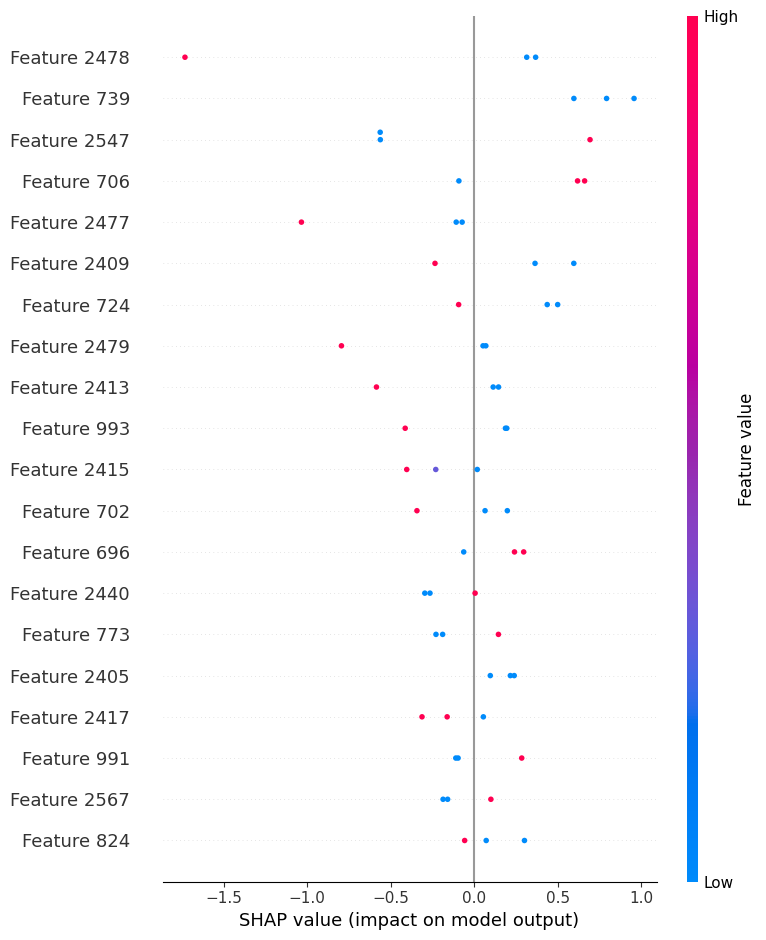

In [24]:
shap.summary_plot(shap_values, X_test)

In [25]:
X_test

array([[3.8380800e+05, 7.9477286e+00, 1.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 3.0000000e+00],
       [7.4752000e+04, 6.2092667e+00, 1.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [3.4713600e+05, 6.5075665e+00, 1.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], shape=(3, 2568), dtype=float32)

In [26]:
i = 0
X_test[i]

array([3.8380800e+05, 7.9477286e+00, 1.0000000e+00, ..., 0.0000000e+00,
       0.0000000e+00, 3.0000000e+00], shape=(2568,), dtype=float32)

In [27]:
i = 0
shap.initjs()
shap.plots.force(explainer.expected_value, shap_values, np.array(X_test, dtype=np.float64)[i])